<a href="https://colab.research.google.com/github/jocelynbrownie27-max/Cholesterol-Project/blob/main/DSRP_2026_Jocelyn_Browne_(CHOLESTEROL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
df = pd.read_csv('/content/NCD_RisC_Nature_2020_Cholesterol_age_standardised_countries.csv')
df

,Country/Region/World,ISO,Sex,Year,Mean total cholesterol (mmol/L),Mean total cholesterol lower 95% uncertainty interval (mmol/L),Mean total cholesterol upper 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),Mean HDL cholesterol (mmol/L),Mean HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)
0,Afghanistan,AFG,Men,1980,4.263545,3.539636,4.959936,2.919134,2.486837,3.339214,1.221839,0.926460,1.497237
1,Afghanistan,AFG,Men,1981,4.266327,3.569655,4.931141,2.934723,2.512884,3.344176,1.214738,0.932500,1.476955
2,Afghanistan,AFG,Men,1982,4.269252,3.612601,4.904159,2.950451,2.543536,3.345615,1.207716,0.935305,1.462378
3,Afghanistan,AFG,Men,1983,4.272437,3.646602,4.881011,2.966397,2.570361,3.353339,1.200752,0.943039,1.444552
4,Afghanistan,AFG,Men,1984,4.275822,3.673783,4.866126,2.982507,2.598309,3.360546,1.193839,0.947619,1.427836
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15595,Zimbabwe,ZWE,Women,2014,4.161298,3.755729,4.588048,2.945255,2.711719,3.174748,1.312036,1.140103,1.483028
15596,Zimbabwe,ZWE,Women,2015,4.157357,3.710967,4.625261,2.945829,2.704246,3.184318,1.310691,1.126460,1.491962
15597,Zimbabwe,ZWE,Women,2016,4.153718,3.661819,4.663383,2.946790,2.694693,3.195830,1.309282,1.110321,1.504699
15598,Zimbabwe,ZWE,Women,2017,4.150368,3.608575,4.709977,2.948084,2.683316,3.207449,1.307992,1.093114,1.517367


cholesterol measured in mmol/L

#Cleaning Data

In [14]:
df.isna().sum()

,0
Country/Region/World,0
ISO,0
Sex,0
Year,0
Mean total cholesterol (mmol/L),0
Mean total cholesterol lower 95% uncertainty interval (mmol/L),0
Mean total cholesterol upper 95% uncertainty interval (mmol/L),0
Mean non-HDL cholesterol (mmol/L),0
Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),0
Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),0


In [15]:
df.duplicated().sum()

np.int64(0)

No duplicated or null values

In [16]:
df.value_counts(['Country/Region/World'])

,count
Country/Region/World,
Afghanistan,78
Albania,78
Algeria,78
American Samoa,78
Andorra,78
...,...
Venezuela,78
Viet Nam,78
Yemen,78


78 total observations for each country, 39 men, 39 women

In [17]:
df.drop(columns=['ISO'], inplace=True)

removed ISO column as I feel I wouldn't need it

In [18]:
df.shape

(15600, 12)

In [19]:
df.columns

Index(['Country/Region/World', 'Sex', 'Year',
       'Mean total cholesterol (mmol/L)',
       'Mean total cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean total cholesterol upper 95% uncertainty interval (mmol/L)',
       'Mean non-HDL cholesterol (mmol/L)',
       'Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L)',
       'Mean HDL cholesterol (mmol/L)',
       'Mean HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)'],
      dtype='object')

In [20]:
df['Country/Region/World'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'China (Hong Kong SAR)', 'Colombia', 'Comoros', 'Congo',
       'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
       'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'DR Congo', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Ethiopia', 'Fiji', 'Finland', 'France', 'French Polynesia',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Gh

In [21]:
df.drop(columns=['Mean total cholesterol lower 95% uncertainty interval (mmol/L)','Mean total cholesterol upper 95% uncertainty interval (mmol/L)','Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L)','Mean HDL cholesterol lower 95% uncertainty interval (mmol/L)',
       'Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)'], inplace=True)
df

,Country/Region/World,Sex,Year,Mean total cholesterol (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean HDL cholesterol (mmol/L)
0,Afghanistan,Men,1980,4.263545,2.919134,1.221839
1,Afghanistan,Men,1981,4.266327,2.934723,1.214738
2,Afghanistan,Men,1982,4.269252,2.950451,1.207716
3,Afghanistan,Men,1983,4.272437,2.966397,1.200752
4,Afghanistan,Men,1984,4.275822,2.982507,1.193839
...,...,...,...,...,...,...
15595,Zimbabwe,Women,2014,4.161298,2.945255,1.312036
15596,Zimbabwe,Women,2015,4.157357,2.945829,1.310691
15597,Zimbabwe,Women,2016,4.153718,2.946790,1.309282
15598,Zimbabwe,Women,2017,4.150368,2.948084,1.307992


# Creating Visuals
---



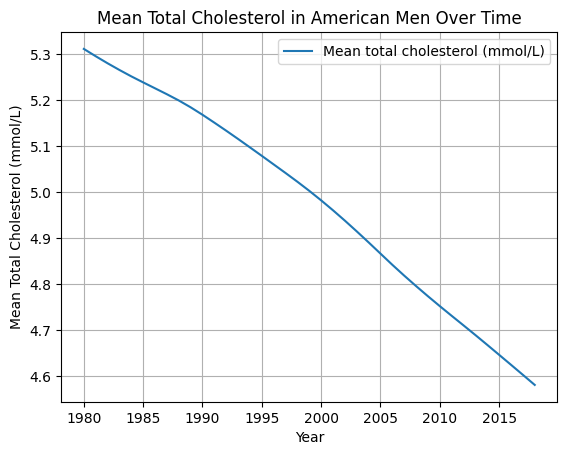

In [30]:
import matplotlib.pyplot as plt

specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Men')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean total cholesterol (mmol/L)", kind="line", title="Mean Total Cholesterol in American Men Over Time", xlabel="Year", ylabel="Mean Total Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

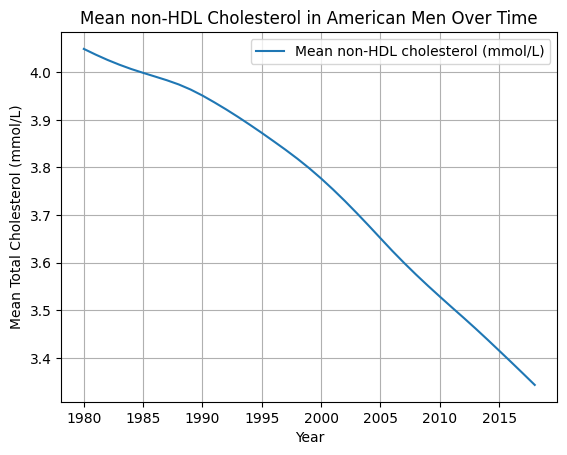

In [37]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Men')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in American Men Over Time", xlabel="Year", ylabel="Mean Total Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

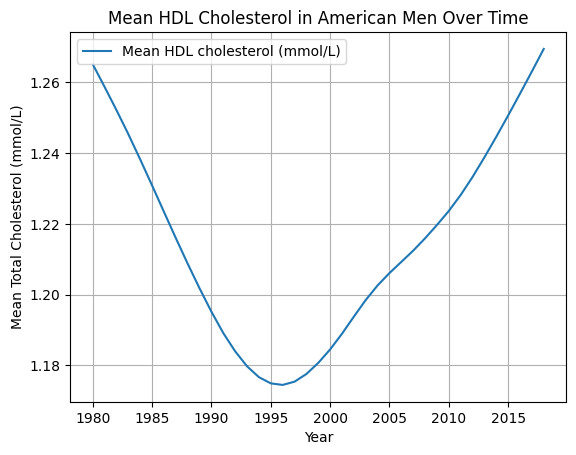

In [41]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Men')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean HDL cholesterol (mmol/L)", kind="line", title="Mean HDL Cholesterol in American Men Over Time", xlabel="Year", ylabel="Mean HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

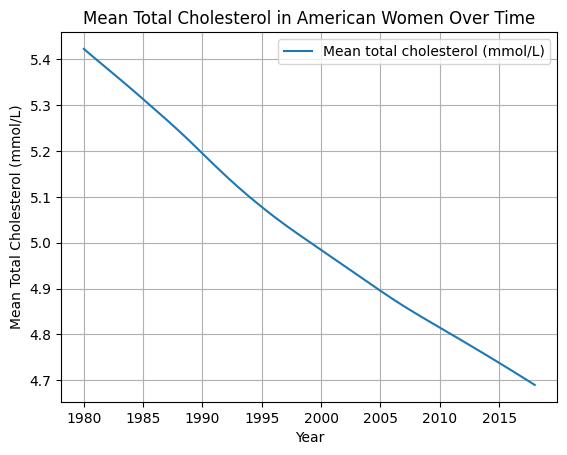

In [38]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean total cholesterol (mmol/L)", kind="line", title="Mean Total Cholesterol in American Women Over Time", xlabel="Year", ylabel="Mean Total Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

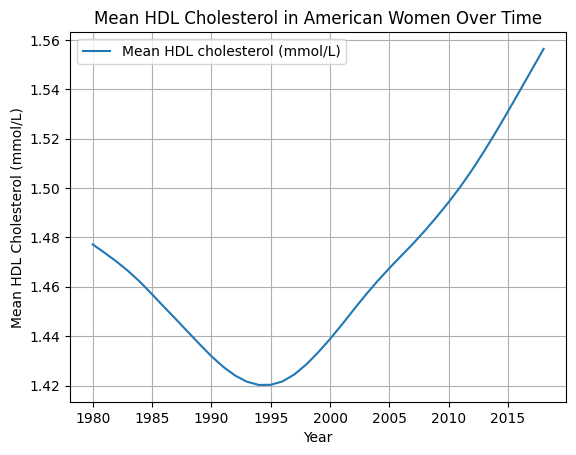

In [56]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean HDL cholesterol (mmol/L)", kind="line", title="Mean HDL Cholesterol in American Women Over Time", xlabel="Year", ylabel="Mean HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

# Non-HDL Cholesterol Levels for Women (LINEPLOTS)

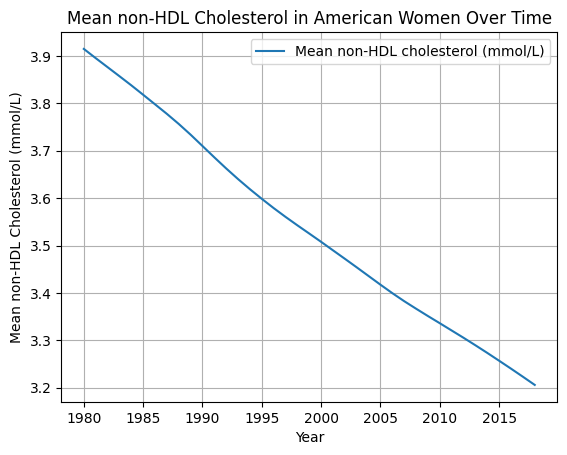

In [43]:
specific_country_df = df[(df['Country/Region/World'] == 'United States of America') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in American Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

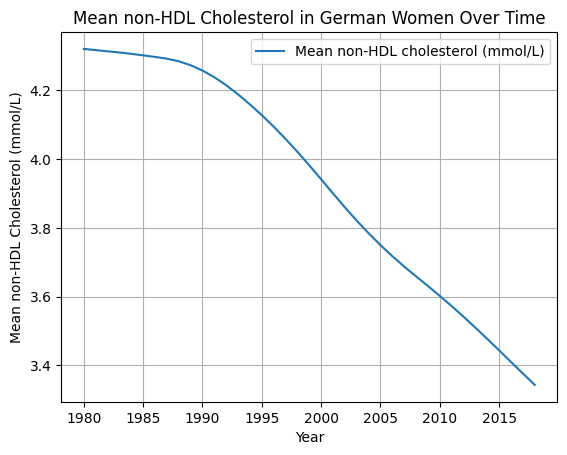

In [47]:
specific_country_df = df[(df['Country/Region/World'] == 'Germany') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in German Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

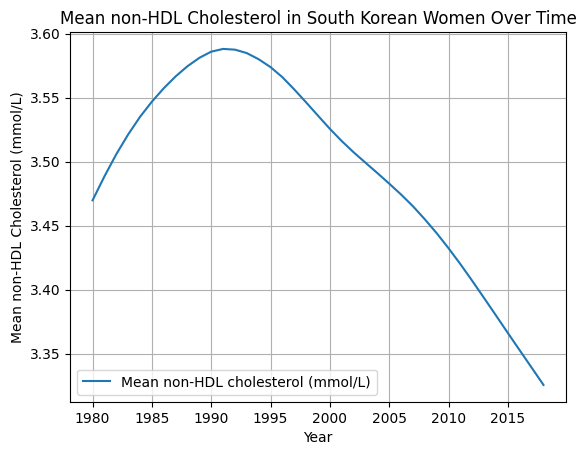

In [48]:
specific_country_df = df[(df['Country/Region/World'] == 'South Korea') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in South Korean Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

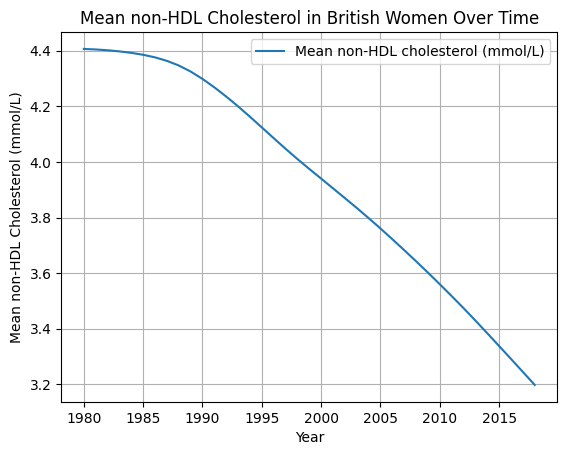

In [49]:
specific_country_df = df[(df['Country/Region/World'] == 'United Kingdom') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in British Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

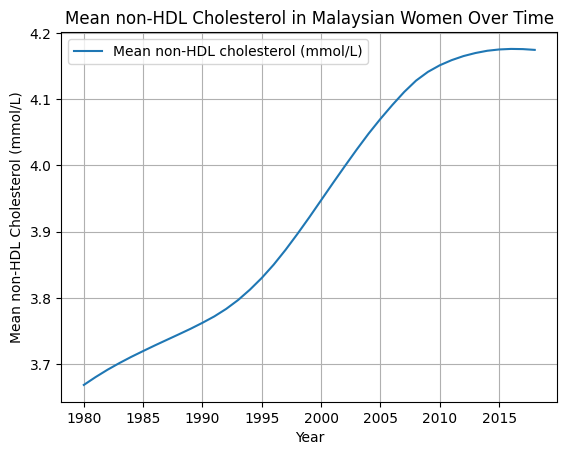

In [50]:
specific_country_df = df[(df['Country/Region/World'] == 'Malaysia') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Malaysian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

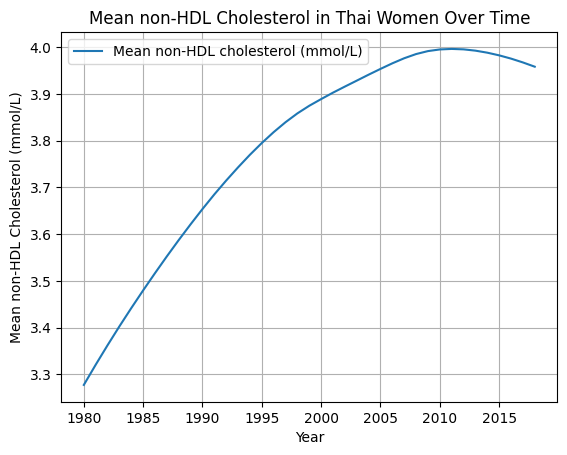

In [51]:
specific_country_df = df[(df['Country/Region/World'] == 'Thailand') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Thai Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

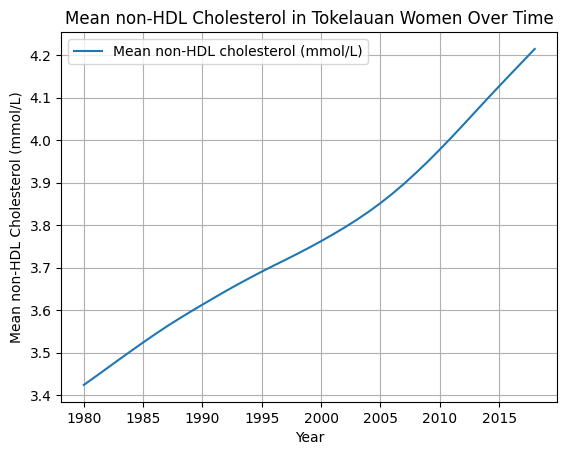

In [52]:
specific_country_df = df[(df['Country/Region/World'] == 'Tokelau') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Tokelauan Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

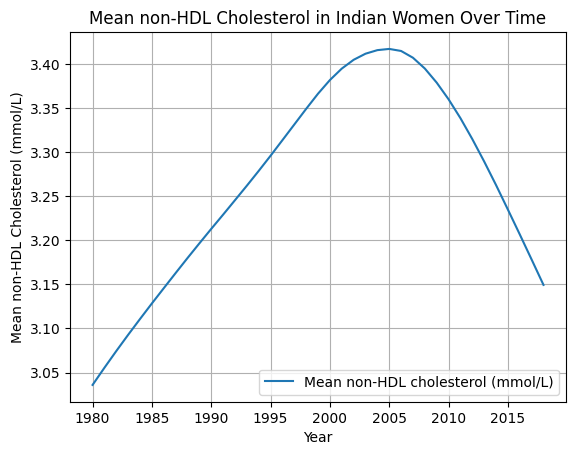

In [53]:
specific_country_df = df[(df['Country/Region/World'] == 'India') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Indian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

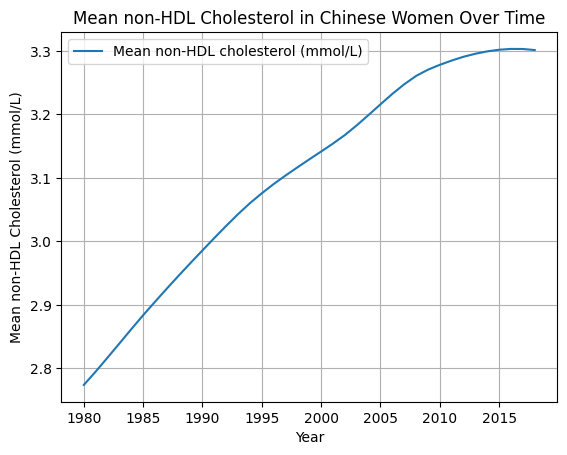

In [54]:
specific_country_df = df[(df['Country/Region/World'] == 'China') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Chinese Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

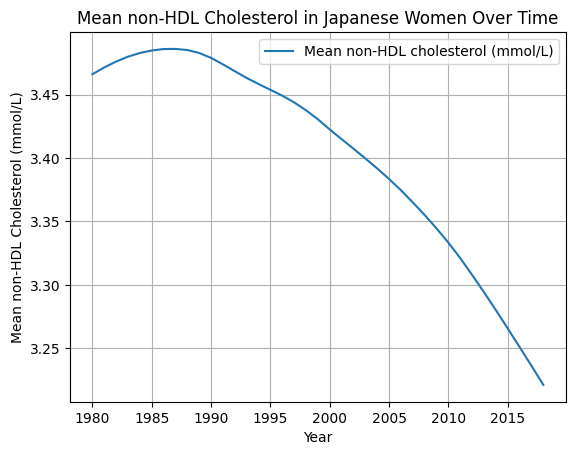

In [55]:
specific_country_df = df[(df['Country/Region/World'] == 'Japan') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Japanese Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

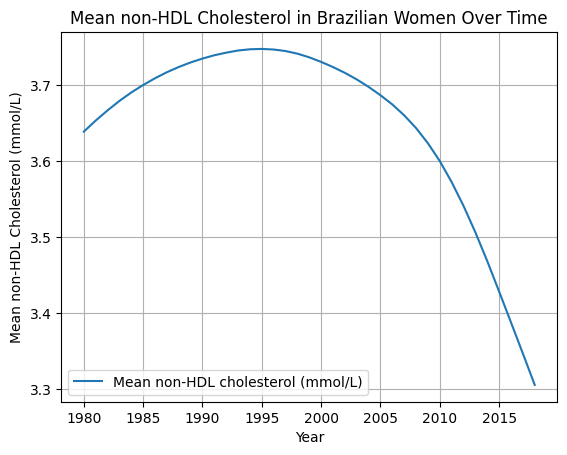

In [95]:
specific_country_df = df[(df['Country/Region/World'] == 'Brazil') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Brazilian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

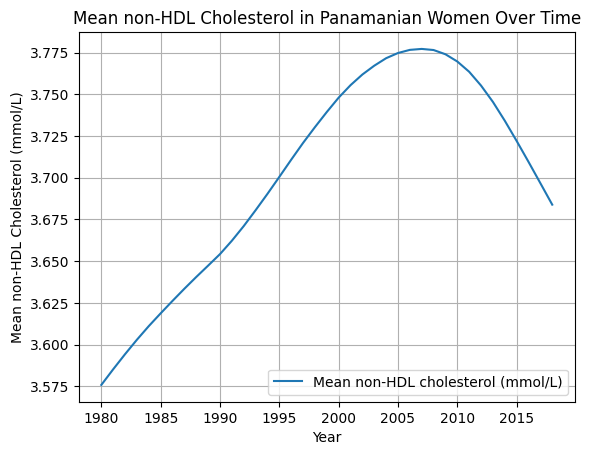

In [94]:
specific_country_df = df[(df['Country/Region/World'] == 'Panama') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Panamanian Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

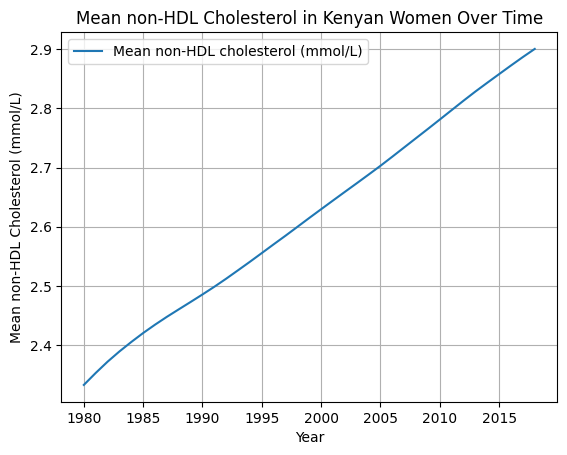

In [93]:
specific_country_df = df[(df['Country/Region/World'] == 'Kenya') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Kenyan Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

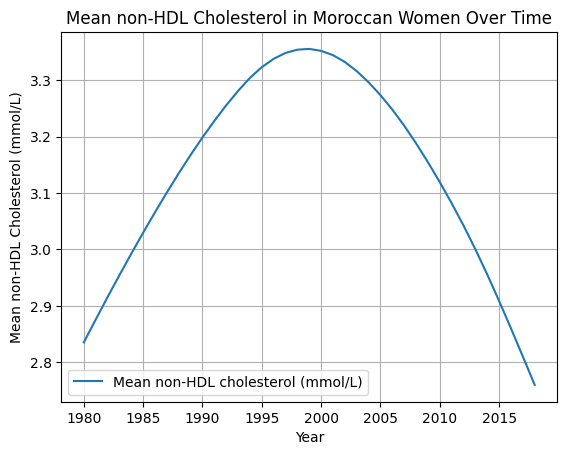

In [92]:
specific_country_df = df[(df['Country/Region/World'] == 'Morocco') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Moroccan Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

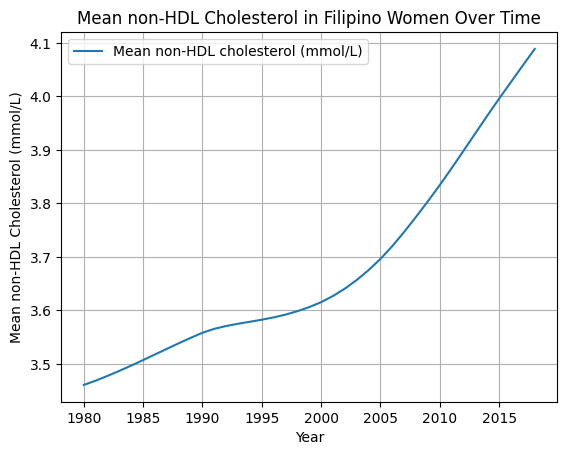

In [91]:
specific_country_df = df[(df['Country/Region/World'] == 'Philippines') & (df['Sex'] == 'Women')].copy()
specific_country_df = specific_country_df.sort_values("Year")
specific_country_df.plot(x="Year", y="Mean non-HDL cholesterol (mmol/L)", kind="line", title="Mean non-HDL Cholesterol in Filipino Women Over Time", xlabel="Year", ylabel="Mean non-HDL Cholesterol (mmol/L)")
plt.grid(True)
plt.show()

# Comparing non-HDL cholesterol in women by country (BARPLOTS)

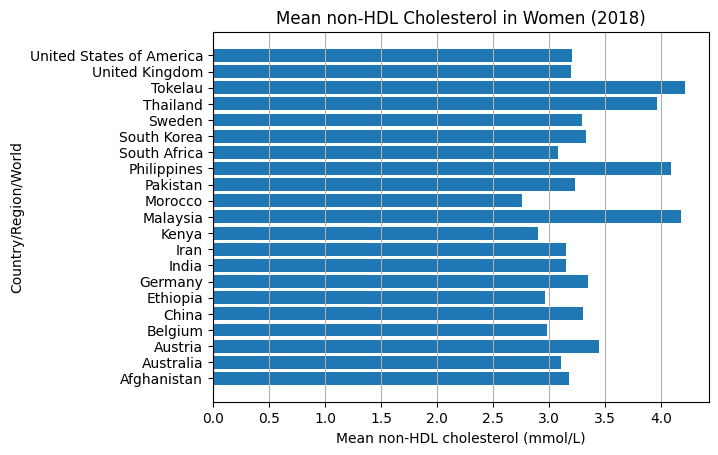

In [99]:
selected_countries = ['Australia', 'Austria', 'United States of America', 'United Kingdom', 'Germany', 'Malaysia', 'Thailand', 'China', 'Kenya', 'Morocco', 'South Africa', 'Ethiopia', 'Tokelau', 'Iran', 'Afghanistan', 'India', 'Pakistan', 'South Korea', 'Philippines', 'Belgium', 'Sweden']
specific_country_df = df[(df['Year'] == 2018) & (df['Sex'] == 'Women') & (df['Country/Region/World'].isin(selected_countries))].copy()
plt.barh(specific_country_df['Country/Region/World'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'])
plt.title('Mean non-HDL Cholesterol in Women (2018)')
plt.xlabel('Mean non-HDL cholesterol (mmol/L)')
plt.ylabel('Country/Region/World')
plt.grid(axis='x')
plt.show()

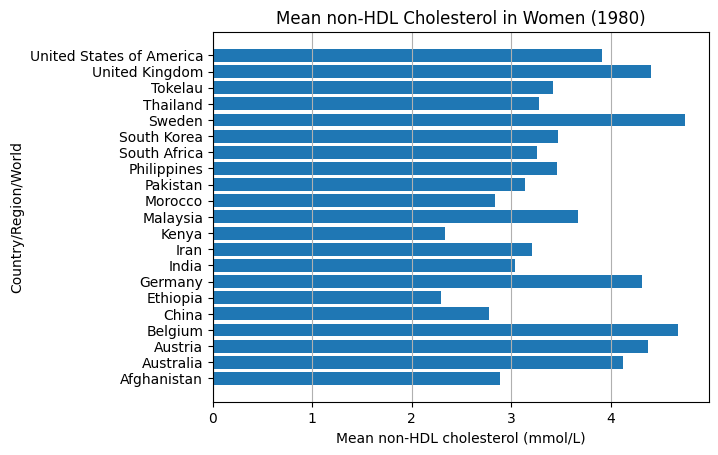

In [100]:
selected_countries = ['Australia', 'Austria', 'United States of America', 'United Kingdom', 'Germany', 'Malaysia', 'Thailand', 'China', 'Kenya', 'Morocco', 'South Africa', 'Ethiopia', 'Tokelau', 'Iran', 'Afghanistan', 'India', 'Pakistan', 'South Korea', 'Philippines', 'Belgium', 'Sweden']
specific_country_df = df[(df['Year'] == 1980) & (df['Sex'] == 'Women') & (df['Country/Region/World'].isin(selected_countries))].copy()
plt.barh(specific_country_df['Country/Region/World'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'])
plt.title('Mean non-HDL Cholesterol in Women (1980)')
plt.xlabel('Mean non-HDL cholesterol (mmol/L)')
plt.ylabel('Country/Region/World')
plt.grid(axis='x')
plt.show()

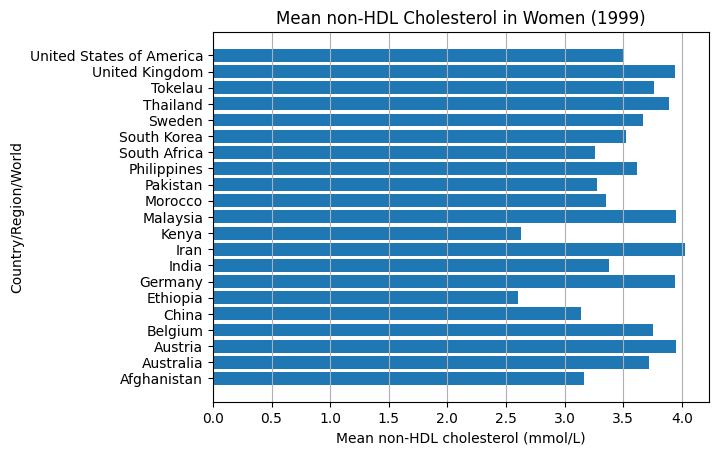

In [101]:
selected_countries = ['Australia', 'Austria', 'United States of America', 'United Kingdom', 'Germany', 'Malaysia', 'Thailand', 'China', 'Kenya', 'Morocco', 'South Africa', 'Ethiopia', 'Tokelau', 'Iran', 'Afghanistan', 'India', 'Pakistan', 'South Korea', 'Philippines', 'Belgium', 'Sweden']
specific_country_df = df[(df['Year'] == 2000) & (df['Sex'] == 'Women') & (df['Country/Region/World'].isin(selected_countries))].copy()
plt.barh(specific_country_df['Country/Region/World'], specific_country_df['Mean non-HDL cholesterol (mmol/L)'])
plt.title('Mean non-HDL Cholesterol in Women (1999)')
plt.xlabel('Mean non-HDL cholesterol (mmol/L)')
plt.ylabel('Country/Region/World')
plt.grid(axis='x')
plt.show()